In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading Data
df = pd.read_csv('customs_clearance_data.csv')


# Step 1: Drop missing release_date rows
df = df.dropna(subset=['release_date'])
print(f"Step 1 - Rows after dropping missing: {len(df)}")

# Step 2: Convert dates
df['entry_date'] = pd.to_datetime(df['entry_date'])
df['accepted_date'] = pd.to_datetime(df['accepted_date'])
df['release_date'] = pd.to_datetime(df['release_date'])

print("Step 2 - Dates converted!")

# Step 3: Verify with df.info()
print("\n=== VERIFY WITH df.info() ===")
df.info()

# Step 4: Show sample
print("\n=== SAMPLE DATES ===")
print(df[['entry_date', 'accepted_date', 'release_date']].head(3))

# Step 5: Calculate clearance hours
df['clearance_hours'] = (df['release_date'] - df['entry_date']).dt.total_seconds() / 3600


Step 1 - Rows after dropping missing: 5145
Step 2 - Dates converted!

=== VERIFY WITH df.info() ===
<class 'pandas.DataFrame'>
Index: 5145 entries, 0 to 5249
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   shipment_id            5145 non-null   str           
 1   entry_no               5145 non-null   str           
 2   hs_code                4892 non-null   str           
 3   product_desc           5145 non-null   str           
 4   supplier               5145 non-null   str           
 5   country_origin         4989 non-null   str           
 6   country_destination    5145 non-null   str           
 7   declared_value_usd     5145 non-null   float64       
 8   invoice_value_usd      5145 non-null   float64       
 9   weight_kg              5145 non-null   float64       
 10  volume_m3              5145 non-null   float64       
 11  broker                 5145 non-null 

In [3]:
# COMPLETE DATA CLEANING PIPELINE 

print("=" * 50)
print("STARTING DATA CLEANING PIPELINE")
print("=" * 50)

# 1. HANDLE MISSING VALUES

print("\n[1] HANDLING MISSING VALUES")

# Drop rows where release_date is missing
df = df.dropna(subset=['release_date'])
print(f"  → Dropped rows with missing release_date: {len(df)} rows remaining")

# Fill missing country_origin with 'UNKNOWN'
df['country_origin'] = df['country_origin'].fillna('UNKNOWN')
print(f"  → Filled missing country_origin: {df['country_origin'].isin(['UNKNOWN']).sum()} rows")

# 2. REMOVE DUPLICATE ENTRIES

print("\n[2] REMOVING DUPLICATE ENTRIES")

duplicate_count = df.duplicated(subset=['entry_no']).sum()
df = df.drop_duplicates(subset=['entry_no'], keep='first')
print(f"  → Removed {duplicate_count} duplicate entries")


# 3. STANDARDIZE TEXT FIELDS

print("\n[3] STANDARDIZING TEXT FIELDS")

text_cols = ['broker', 'port_of_entry', 'country_origin', 'supplier', 'product_desc', 'incoterm']
for col in text_cols:
    df[col] = df[col].astype(str).str.upper().str.strip()
    df[col] = df[col].replace(['', 'NAN', 'NONE'], 'UNKNOWN')
print(f"  → Standardized {len(text_cols)} text columns")

# 4. DATE VALIDATION

print("\n[4] VALIDATING DATES")

df['entry_date'] = pd.to_datetime(df['entry_date'])
df['accepted_date'] = pd.to_datetime(df['accepted_date'])
df['release_date'] = pd.to_datetime(df['release_date'])

invalid_dates = df[df['release_date'] < df['entry_date']]
df.loc[df['release_date'] < df['entry_date'], 'release_date'] = df.loc[df['release_date'] < df['entry_date'], 'entry_date'] + pd.Timedelta(hours=24)
print(f"  → Fixed {len(invalid_dates)} invalid dates")

# 5. OUTLIER TREATMENT

print("\n[5] TREATING OUTLIERS")

weight_95 = df['weight_kg'].quantile(0.95)
weight_capped = (df['weight_kg'] > weight_95).sum()
df['weight_kg'] = df['weight_kg'].clip(upper=weight_95)
print(f"  → Capped {weight_capped} weight outliers at {weight_95:.2f} kg")

value_99 = df['declared_value_usd'].quantile(0.99)
value_capped = (df['declared_value_usd'] > value_99).sum()
df['declared_value_usd'] = df['declared_value_usd'].clip(upper=value_99)
print(f"  → Capped {value_capped} value outliers at ${value_99:,.2f}")

# 6. HS CODE CLEANING (YOUR CODE)

print("\n[6] CLEANING HS CODES")

# Step 1: Remove 'X' from HS codes and clean
df['hs_code_clean'] = df['hs_code'].astype(str).str.replace('X', '').str.strip()
df['hs_code_clean'] = df['hs_code_clean'].replace(['nan', 'None', ''], 'UNKNOWN')

# Step 2: Extract HS category (first 2 digits)
df['hs_category'] = df['hs_code_clean'].str[:2]

# Step 3: Flag invalid HS codes (not 6 digits or not numeric)
df['hs_code_invalid'] = (
    ~df['hs_code_clean'].str.isdigit() | 
    (df['hs_code_clean'].str.len() != 6)
).astype(int)

# Step 4: Replace original hs_code with cleaned version
df['hs_code'] = df['hs_code_clean']
df = df.drop(columns=['hs_code_clean'])

print(f"  → Invalid HS codes: {df['hs_code_invalid'].sum()}")
print(f"  → Unknown HS codes: {(df['hs_code'] == 'UNKNOWN').sum()}")

# 7. LICENSE COMPLIANCE FLAG

print("\n[7] FLAGGING LICENSE COMPLIANCE")

df['license_missing'] = ((df['license_required'] == 'Y') & (df['license_obtained'] == 'N')).astype(int)
print(f"  → Missing licenses flagged: {df['license_missing'].sum()}")

STARTING DATA CLEANING PIPELINE

[1] HANDLING MISSING VALUES
  → Dropped rows with missing release_date: 5145 rows remaining
  → Filled missing country_origin: 156 rows

[2] REMOVING DUPLICATE ENTRIES
  → Removed 361 duplicate entries

[3] STANDARDIZING TEXT FIELDS
  → Standardized 6 text columns

[4] VALIDATING DATES
  → Fixed 0 invalid dates

[5] TREATING OUTLIERS
  → Capped 240 weight outliers at 4825.15 kg
  → Capped 48 value outliers at $148,504.06

[6] CLEANING HS CODES
  → Invalid HS codes: 240
  → Unknown HS codes: 4

[7] FLAGGING LICENSE COMPLIANCE
  → Missing licenses flagged: 64


Feature Engineering

In [4]:
print("\n[8] CREATING NEW FEATURES")

# Clearance time in hours
df['clearance_hours'] = (df['release_date'] - df['entry_date']).dt.total_seconds() / 3600

# Slow clearance flag (> 48 hours)
df['slow_clearance'] = (df['clearance_hours'] > 48).astype(int)

# Valuation discrepancy
df['valuation_discrepancy_pct'] = ((df['invoice_value_usd'] / df['declared_value_usd']) - 1) * 100
df['high_discrepancy'] = (df['valuation_discrepancy_pct'] > 20).astype(int)

# High-risk origin flag
high_risk_origins = ['CHINA', 'INDIA', 'TURKEY', 'VIETNAM', 'THAILAND']
df['high_risk_origin'] = df['country_origin'].isin(high_risk_origins).astype(int)

# Demurrage cost
df['excess_days'] = np.maximum(0, (df['clearance_hours'] - 48) / 24)
df['demurrage_cost'] = df['excess_days'] * 50

print(f"  → Created 7 new features")

# 9. FINAL SUMMARY

print("\n" + "=" * 50)
print("DATA CLEANING COMPLETE")
print("=" * 50)
print(f"Final dataset shape: {df.shape}")
print(f"Total columns: {len(df.columns)}")

print("\n=== SAMPLE CLEANED DATA ===")
df.head(3)


[8] CREATING NEW FEATURES
  → Created 7 new features

DATA CLEANING COMPLETE
Final dataset shape: (4784, 35)
Total columns: 35

=== SAMPLE CLEANED DATA ===


,shipment_id,entry_no,hs_code,product_desc,supplier,country_origin,country_destination,declared_value_usd,invoice_value_usd,weight_kg,...,slow_clearance,clearance_hours,hs_category,hs_code_invalid,license_missing,valuation_discrepancy_pct,high_discrepancy,high_risk_origin,excess_days,demurrage_cost
0,SHIP000001,22EMKIM499458,303286,MEDICINAL PREPARATIONS,AGRITECH SOLUTIONS,TANZANIA,UGANDA,25061.0,25074.42,2950.44,...,0,4.0,30,0,0,0.053549,0,0,0.0,0.0
1,SHIP000002,22EMKIM437930,306514,MEDICINAL PREPARATIONS,INDUSTRIAL SUPPLY CO,GHANA,SOUTH AFRICA,141068.0,208861.59,357.08,...,0,4.0,30,0,0,48.057384,1,0,0.0,0.0
2,SHIP000003,22EMKIM404207,398428,PLASTIC COMPONENTS,MEDICARE SOLUTIONS,MOZAMBIQUE,KENYA,45362.0,44204.41,4215.83,...,0,0.0,39,0,0,-2.551894,0,0,0.0,0.0


Question: Which HS code categories have the highest duty rates and compliance risk?

In [5]:
hs_risk = df.groupby('hs_category').agg(
    total_shipments=('entry_no', 'count'),
    avg_duty_usd=('duty_amount_usd', 'mean'),
    license_required_pct=('license_required', lambda x: (x == 'Y').mean()),
    slow_clearance_pct=('slow_clearance', 'mean')
).round(2).sort_values('avg_duty_usd', ascending=False)

hs_risk

,total_shipments,avg_duty_usd,license_required_pct,slow_clearance_pct
hs_category,,,,
87,463,15198.65,0.00,0.17
73,477,14432.22,0.00,0.14
30,432,7802.63,0.30,0.14
85,432,7461.69,0.11,0.15
UN,4,6115.24,0.00,0.00
40,441,5798.54,0.00,0.17
70,433,5691.59,0.00,0.14
39,447,5685.85,0.00,0.15
62,458,5614.27,0.00,0.15


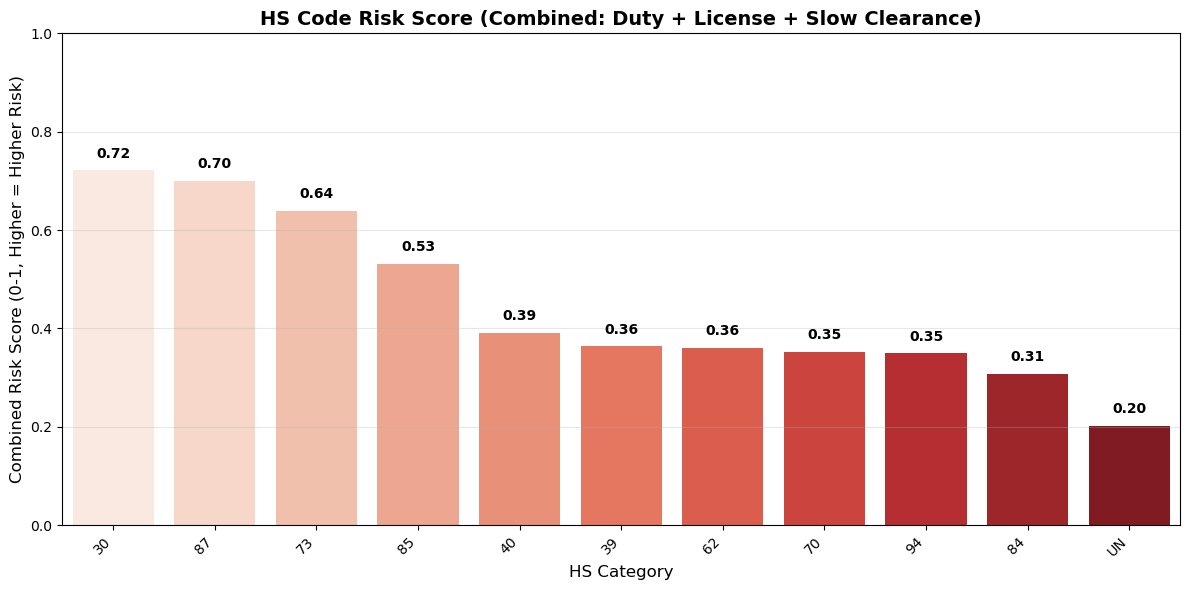

In [6]:
#HS CODE RISK SCORE (COMBINED)

# Normalize each risk factor (0-1 scale, where 1 = highest risk)
hs_risk_norm = hs_risk.copy()
hs_risk_norm['duty_score'] = hs_risk_norm['avg_duty_usd'] / hs_risk_norm['avg_duty_usd'].max()
hs_risk_norm['license_score'] = hs_risk_norm['license_required_pct'] / hs_risk_norm['license_required_pct'].max()
hs_risk_norm['slow_score'] = hs_risk_norm['slow_clearance_pct'] / hs_risk_norm['slow_clearance_pct'].max()

# Weighted combined risk score (duty 50%, license 30%, slow 20%)
weights = {'duty': 0.50, 'license': 0.30, 'slow': 0.20}
hs_risk_norm['combined_risk'] = (
    weights['duty'] * hs_risk_norm['duty_score'] +
    weights['license'] * hs_risk_norm['license_score'] +
    weights['slow'] * hs_risk_norm['slow_score']
)

hs_risk_norm = hs_risk_norm.sort_values('combined_risk', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=hs_risk_norm.reset_index(), 
            x='hs_category', 
            y='combined_risk', 
            palette='Reds')
plt.title('HS Code Risk Score (Combined: Duty + License + Slow Clearance)', fontsize=14, fontweight='bold')
plt.xlabel('HS Category', fontsize=12)
plt.ylabel('Combined Risk Score (0-1, Higher = Higher Risk)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(hs_risk_norm['combined_risk']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('images/hs_risk_score.png', dpi=300, bbox_inches='tight')
plt.show()

=== VALUATION DISCREPANCY BY BROKER ===
                          total_shipments  high_disc_count  high_disc_pct  \
broker                                                                      
AGILITY LOGISTICS                     220               54           0.25   
EXPEDITORS INTERNATIONAL              237               59           0.25   
PANALPINA                             198               45           0.23   
DHL GLOBAL FORWARDING                2462              562           0.23   
BOLLORE LOGISTICS                     683              149           0.22   
KUEHNE NAGEL                          984              218           0.22   

                          avg_disc_pct  avg_declared  avg_invoice  
broker                                                             
AGILITY LOGISTICS                10.38      76017.84     84091.63  
EXPEDITORS INTERNATIONAL         11.66      74831.55     82642.71  
PANALPINA                         9.72      74855.68     81192.58  
DHL

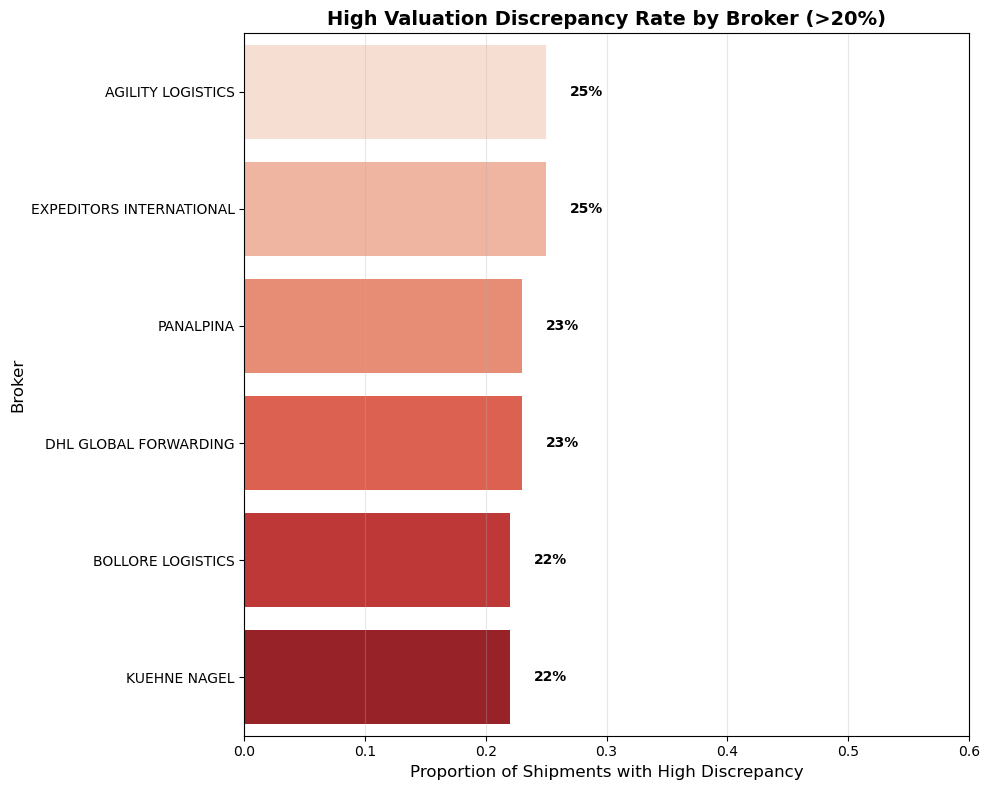

In [11]:
# VALUATION DISCREPANCY ANALYSIS 

# Calculate valuation discrepancy
df['valuation_discrepancy_pct'] = ((df['invoice_value_usd'] / df['declared_value_usd']) - 1) * 100
df['high_discrepancy'] = (df['valuation_discrepancy_pct'] > 20).astype(int)

# Summary by broker
disc_summary = df.groupby('broker').agg(
    total_shipments=('entry_no', 'count'),
    high_disc_count=('high_discrepancy', 'sum'),
    high_disc_pct=('high_discrepancy', 'mean'),
    avg_disc_pct=('valuation_discrepancy_pct', 'mean'),
    avg_declared=('declared_value_usd', 'mean'),
    avg_invoice=('invoice_value_usd', 'mean')
).round(2).sort_values('high_disc_pct', ascending=False)

print("=== VALUATION DISCREPANCY BY BROKER ===")
print(disc_summary)

# VISUALIZATION 

# Sort data for horizontal display (highest to lowest)
disc_plot = disc_summary.sort_values('high_disc_pct', ascending=False).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=disc_plot, 
            y='broker',          # y-axis = broker names
            x='high_disc_pct',   # x-axis = discrepancy rate
            palette='Reds')
plt.title('High Valuation Discrepancy Rate by Broker (>20%)', fontsize=14, fontweight='bold')
plt.xlabel('Proportion of Shipments with High Discrepancy', fontsize=12)
plt.ylabel('Broker', fontsize=12)
plt.xlim(0, 0.6)  # Set x-axis limit to 60%
plt.grid(True, alpha=0.3, axis='x')

# Add value labels at the end of each bar
for i, v in enumerate(disc_plot['high_disc_pct']):
    plt.text(v + 0.02, i, f'{v*100:.0f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/valuation_discrepancy_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()